In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

titanic = sns.load_dataset("titanic")

print("Dataset Shape:", titanic.shape)
print(titanic.head())

Dataset Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

X = titanic[features]
y = titanic['survived']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   pclass     sex   age  sibsp  parch     fare embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target:
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [4]:
numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (712, 7)
Testing Set Shape: (179, 7)


In [5]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Classifier Test Accuracy: {accuracy * 100:.2f}%")

Decision Tree Classifier Test Accuracy: 79.33%


In [6]:
print("--- Classification Report ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Survived', 'Survived']
))

--- Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.77      0.95      0.85       110
    Survived       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



In [7]:
cm = confusion_matrix(y_test, y_pred)

print("--- Confusion Matrix ---")
print(cm)

--- Confusion Matrix ---
[[104   6]
 [ 31  38]]


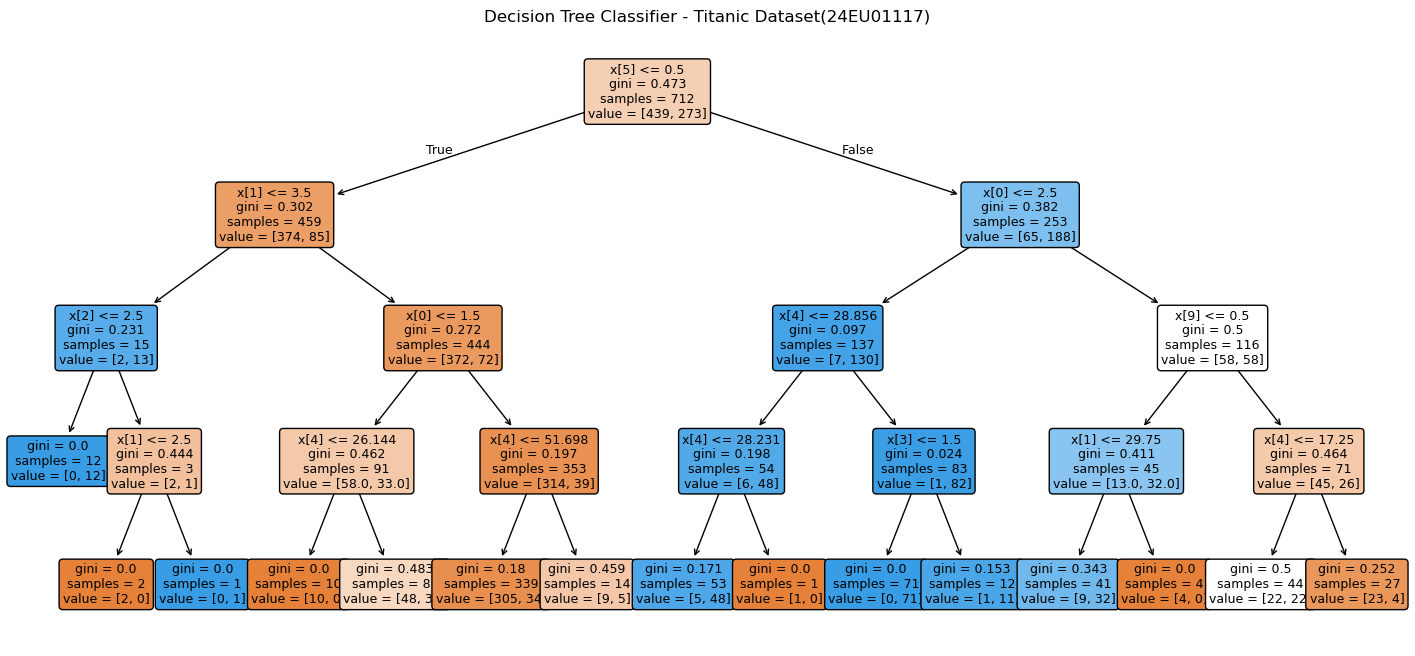

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_model = model.named_steps['classifier']
preprocessed_X_train = model.named_steps['preprocessor'].transform(X_train)

plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier - Titanic Dataset(24EU01117)")
plt.show()

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)
print(X.head())

Dataset Shape: (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [11]:
print("Target Variable:")
print(y.head())

Target Variable:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (16512, 8)
Testing Set Shape: (4128, 8)


In [13]:
tree_reg = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_reg.fit(X_train, y_train)

y_pred = tree_reg.predict(X_test)

In [14]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Coefficient of Determination: {r2:.4f}")

Mean Squared Error (MSE): 0.5245
Root Mean Squared Error (RMSE): 0.7242
R2 Coefficient of Determination: 0.5997


In [15]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

    Actual  Predicted
0  0.47700   1.168573
1  0.45800   1.271581
2  5.00001   3.199582
3  2.18600   2.204763
4  2.78000   1.642797
5  1.58700   2.337900
6  1.98200   1.920621
7  1.57500   1.642797
8  3.40000   2.375496
9  4.46600   4.778789


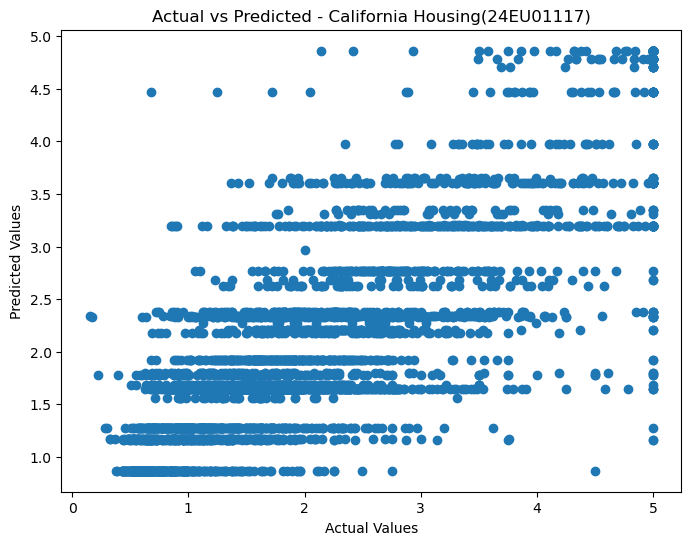

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - California Housing(24EU01117)")

plt.show()

In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_reg.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

      Feature  Importance
0      MedInc    0.771212
5    AveOccup    0.128407
1    HouseAge    0.041621
2    AveRooms    0.031261
6    Latitude    0.022049
4  Population    0.002485
7   Longitude    0.002097
3   AveBedrms    0.000869


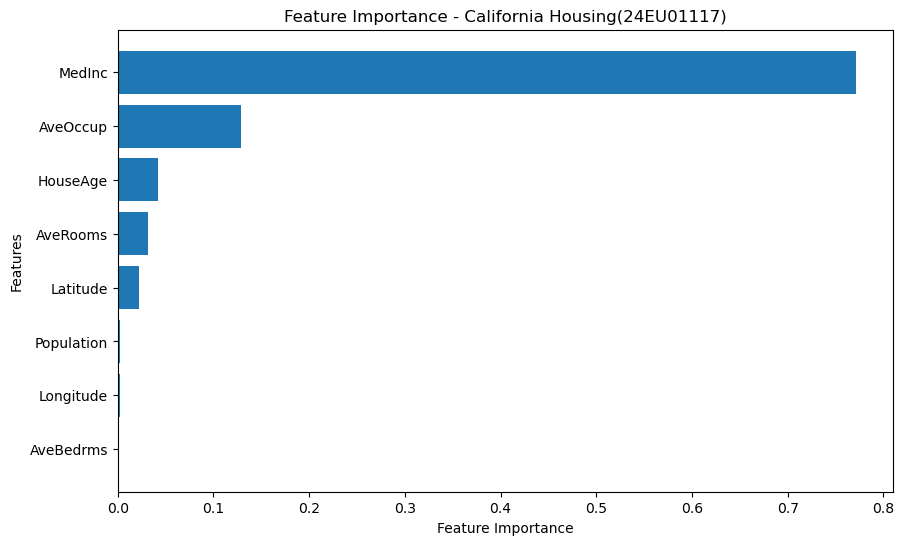

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - California Housing(24EU01117)")

plt.gca().invert_yaxis()

plt.show()